# Earthquake Effect Prediction — Physics-Informed Model + Smooth Blue Heatmap

This notebook is an updated version of your original notebook.

Main changes added:

1. Earthquake training data collection from USGS ShakeMap grids.
2. Correct distance calculation from epicentre/source to every grid point.
3. Physics-based features:
   - hypocentral distance
   - log distance
   - inverse hypocentral distance
   - magnitude-distance interaction features
4. LightGBM model with monotonic constraints so the model follows basic physics:
   - higher magnitude should increase predicted effect
   - larger distance should decrease predicted effect
   - larger depth usually decreases surface effect
5. Full circular area prediction around epicentre, not only ring lines.
6. Smooth blue heatmap in the notebook.
7. JSON and CSV export for frontend use.

## 0. Imports

Run this first. If `lightgbm` or `folium` is missing, uncomment the install line and run it once.

In [1]:
# Uncomment only if these packages are not installed
%pip install lightgbm folium

import os
import io
import json
import math
import time
import zipfile
import requests
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET

from sklearn.neighbors import BallTree
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from lightgbm import LGBMRegressor

import folium
from folium.plugins import HeatMap
from IPython.display import FileLink

EARTH_RADIUS_KM = 6371.0

Note: you may need to restart the kernel to use updated packages.


## 1. Collect earthquake events that have ShakeMap products

This gets earthquakes inside India-region bounds and keeps only events with ShakeMap data.

In [2]:
def get_india_earthquakes_with_shakemap(
    starttime="2000-01-01",
    endtime="2026-05-21",
    minmagnitude=5.0
):
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

    params = {
        "format": "geojson",
        "starttime": starttime,
        "endtime": endtime,
        "minlatitude": 6,
        "maxlatitude": 38,
        "minlongitude": 68,
        "maxlongitude": 98,
        "minmagnitude": minmagnitude,
        "producttype": "shakemap",
        "orderby": "time-asc"
    }

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()

    rows = []

    for feature in data.get("features", []):
        prop = feature["properties"]
        lon, lat, depth = feature["geometry"]["coordinates"]

        rows.append({
            "event_id": feature["id"],
            "date": pd.to_datetime(prop["time"], unit="ms"),
            "source_lon": lon,
            "source_lat": lat,
            "source_magnitude": prop["mag"],
            "source_depth": depth
        })

    return pd.DataFrame(rows)

In [3]:
events_df = get_india_earthquakes_with_shakemap(
    starttime="2000-01-01",
    endtime="2026-05-21",
    minmagnitude=5.0
)

print(events_df.head())
print("Number of events:", events_df.shape[0])

     event_id                    date  source_lon  source_lat  \
0  usp0009ks9 2000-01-05 09:45:18.710      92.700      32.222   
1  usp0009mbv 2000-01-19 07:09:33.580      70.379      36.372   
2  usp0009pmc 2000-03-12 18:03:56.270      73.672      17.099   
3  usp0009sv4 2000-05-12 23:10:29.980      70.657      35.975   
4  usp0009u6j 2000-06-07 21:46:55.900      97.238      26.856   

   source_magnitude  source_depth  
0               5.5          33.0  
1               6.0         206.9  
2               5.0          33.0  
3               6.3         107.7  
4               6.3          33.0  
Number of events: 417


## 2. Download and parse ShakeMap grid data

Each ShakeMap grid contains observed or estimated intensity values. We use `MMI` as the target effect.

In [4]:
def find_grid_key(contents):
    possible_keys = [
        "download/grid.xml.zip",
        "download/grid.xml",
        "grid.xml.zip",
        "grid.xml"
    ]

    for key in possible_keys:
        if key in contents:
            return key

    for key in contents.keys():
        if "grid.xml" in key.lower():
            return key

    return None


def download_shakemap_grid(event_id):
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

    params = {
        "eventid": event_id,
        "format": "geojson"
    }

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    event_data = response.json()

    products = event_data.get("properties", {}).get("products", {})

    if "shakemap" not in products:
        return None

    shakemap = products["shakemap"][0]
    contents = shakemap.get("contents", {})

    grid_key = find_grid_key(contents)

    if grid_key is None:
        print("No grid file found for", event_id)
        return None

    grid_url = contents[grid_key]["url"]
    grid_response = requests.get(grid_url, timeout=60)
    grid_response.raise_for_status()

    if grid_key.endswith(".zip"):
        z = zipfile.ZipFile(io.BytesIO(grid_response.content))
        grid_file = [name for name in z.namelist() if name.endswith("grid.xml")][0]
        xml_data = z.read(grid_file)
    else:
        xml_data = grid_response.content

    root = ET.fromstring(xml_data)

    fields = []

    for field in root.findall(".//{*}grid_field"):
        index = int(field.attrib["index"])
        name = field.attrib["name"].upper()
        fields.append((index, name))

    fields = [name for index, name in sorted(fields)]

    grid_data = root.find(".//{*}grid_data")

    if grid_data is None or grid_data.text is None:
        return None

    rows = []

    for line in grid_data.text.strip().splitlines():
        rows.append(line.split())

    df = pd.DataFrame(rows, columns=fields)
    df = df.astype(float)

    if "LON" not in df.columns or "LAT" not in df.columns or "MMI" not in df.columns:
        print("Required LON/LAT/MMI columns missing for", event_id)
        return None

    return df[["LON", "LAT", "MMI"]].copy()

## 3. Distance and custom grid functions

This creates a grid around each earthquake source and assigns each grid point its nearest ShakeMap effect value.

In [5]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return EARTH_RADIUS_KM * c


def calculate_haversine_distance(lon1, lat1, lon2, lat2):
    return haversine_distance_km(lat1, lon1, lat2, lon2)


def create_grid_around_source(source_lat, source_lon, radius_km=1000, grid_size_km=50):
    lat_step = grid_size_km / 111.0
    lon_step = grid_size_km / (111.0 * np.cos(np.radians(source_lat)))

    lat_min = source_lat - radius_km / 111.0
    lat_max = source_lat + radius_km / 111.0

    lon_min = source_lon - radius_km / (111.0 * np.cos(np.radians(source_lat)))
    lon_max = source_lon + radius_km / (111.0 * np.cos(np.radians(source_lat)))

    lats = np.arange(lat_min, lat_max + lat_step, lat_step)
    lons = np.arange(lon_min, lon_max + lon_step, lon_step)

    grid_points = []

    for lat in lats:
        for lon in lons:
            dist = haversine_distance_km(source_lat, source_lon, lat, lon)

            if dist <= radius_km:
                grid_points.append({
                    "grid_lon": lon,
                    "grid_lat": lat,
                    "distance from source": dist
                })

    return pd.DataFrame(grid_points)

In [6]:
def assign_effect_to_custom_grid(custom_grid_df, shakemap_df):
    shake_points_rad = np.radians(shakemap_df[["LAT", "LON"]].values)
    custom_points_rad = np.radians(custom_grid_df[["grid_lat", "grid_lon"]].values)

    tree = BallTree(shake_points_rad, metric="haversine")
    distances, indices = tree.query(custom_points_rad, k=1)

    nearest_mmi = shakemap_df.iloc[indices.flatten()]["MMI"].values

    result = custom_grid_df.copy()
    result["effect"] = nearest_mmi

    return result

In [7]:
def prepare_one_earthquake_dataframe(event_row, radius_km=1000, grid_size_km=50):
    event_id = event_row["event_id"]

    shakemap_df = download_shakemap_grid(event_id)

    if shakemap_df is None:
        return None

    custom_grid_df = create_grid_around_source(
        source_lat=event_row["source_lat"],
        source_lon=event_row["source_lon"],
        radius_km=radius_km,
        grid_size_km=grid_size_km
    )

    effect_grid_df = assign_effect_to_custom_grid(custom_grid_df, shakemap_df)

    final_df = pd.DataFrame({
        "event_id": event_row["event_id"],
        "date": event_row["date"],
        "source_lon": event_row["source_lon"],
        "source_lat": event_row["source_lat"],
        "source_magnitude": event_row["source_magnitude"],
        "source_depth": event_row["source_depth"],
        "grid_lon": effect_grid_df["grid_lon"],
        "grid_lat": effect_grid_df["grid_lat"],
        "distance from source": effect_grid_df["distance from source"],
        "effect": effect_grid_df["effect"]
    })

    return final_df


def build_training_dataframe(events_df, radius_km=1000, grid_size_km=50, max_events=None):
    all_rows = []

    if max_events is not None:
        events_df = events_df.head(max_events).copy()

    for i, event_row in events_df.iterrows():
        print("Processing", i, event_row["event_id"])

        try:
            event_df = prepare_one_earthquake_dataframe(
                event_row,
                radius_km=radius_km,
                grid_size_km=grid_size_km
            )

            if event_df is not None and not event_df.empty:
                all_rows.append(event_df)

        except Exception as e:
            print("Error:", event_row["event_id"], e)

        time.sleep(0.5)

    if len(all_rows) == 0:
        return pd.DataFrame(columns=[
            "event_id", "date", "source_lon", "source_lat", "source_magnitude",
            "source_depth", "grid_lon", "grid_lat", "distance from source", "effect"
        ])

    return pd.concat(all_rows, ignore_index=True)

## 4. Build or load the training dataset

This cell first checks whether a CSV already exists. If it exists, it loads that file. Otherwise, it downloads and builds the training dataset.

For a quick test, set `MAX_EVENTS = 5` or `10`. For full training, use `MAX_EVENTS = None`.

In [8]:
DATA_CSV = "earthquake_training_data_full.csv"

RADIUS_KM_FOR_TRAINING = 1000
GRID_SIZE_KM_FOR_TRAINING = 25
MAX_EVENTS = None     # use 5 or 10 first for testing, None for full data

if os.path.exists(DATA_CSV):
    print("Loading existing CSV:", DATA_CSV)
    training_df = pd.read_csv(DATA_CSV)
else:
    print("Building training data from USGS ShakeMap data...")
    training_df = build_training_dataframe(
        events_df,
        radius_km=RADIUS_KM_FOR_TRAINING,
        grid_size_km=GRID_SIZE_KM_FOR_TRAINING,
        max_events=MAX_EVENTS
    )
    training_df.to_csv(DATA_CSV, index=False)
    print("Saved:", DATA_CSV)

print(training_df.head())
print(training_df.shape)

Building training data from USGS ShakeMap data...
Processing 0 usp0009ks9
Processing 1 usp0009mbv
Processing 2 usp0009pmc
Processing 3 usp0009sv4
Processing 4 usp0009u6j
Processing 5 usp0009wpm
Processing 6 usp0009zr1
Processing 7 usp000a1m4
Processing 8 usp000a2rc
Processing 9 usp000a3hq
Processing 10 usp000a8ds
Processing 11 usp000a8du
Processing 12 usp000a8dz
Processing 13 usp000a8e2
Processing 14 usp000a8ec
Processing 15 usp000a8hm
Processing 16 usp000a8je
Processing 17 usp000a8yc
Processing 18 usp000a99q
Processing 19 usp000a9xc
Processing 20 usp000aaae
Processing 21 usp000aayq
Processing 22 usp000afvt
Processing 23 usp000ajnb
Processing 24 usp000apsa
Processing 25 usp000asvm
Processing 26 usp000asvr
Processing 27 usp000at3t
Processing 28 usp000atcf
Processing 29 usp000atjx
Processing 30 usp000avr3
Processing 31 usp000azhb
Processing 32 usp000azhc
Processing 33 usp000b10y
Processing 34 usp000b15n
Processing 35 usp000b283
Processing 36 usp000b5h4
Processing 37 usp000b752
Processing

## 5. Data cleaning and distance check

This makes sure the target column is named `effect` and distance exists.

In [9]:
# If your target column has a different name, map it here.
# In the current notebook, ShakeMap MMI is already stored as 'effect'.
if "effect" not in training_df.columns:
    possible_target_cols = ["MMI", "mmi", "intensity", "Intensity", "PGA", "pga"]
    found = None
    for col in possible_target_cols:
        if col in training_df.columns:
            found = col
            break
    if found is None:
        raise ValueError("No target column found. Please rename your target column to 'effect'.")
    training_df = training_df.rename(columns={found: "effect"})

# If distance is missing, calculate it from source and grid coordinates.
if "distance from source" not in training_df.columns:
    training_df["distance from source"] = calculate_haversine_distance(
        training_df["source_lon"],
        training_df["source_lat"],
        training_df["grid_lon"],
        training_df["grid_lat"]
    )

required_cols = [
    "source_lon", "source_lat", "source_magnitude", "source_depth",
    "distance from source", "effect"
]

training_df = training_df.dropna(subset=required_cols).copy()
training_df[required_cols] = training_df[required_cols].astype(float)

print(training_df[required_cols].head())
print(training_df.info())

   source_lon  source_lat  source_magnitude  source_depth  \
0        92.7      32.222               5.5          33.0   
1        92.7      32.222               5.5          33.0   
2        92.7      32.222               5.5          33.0   
3        92.7      32.222               5.5          33.0   
4        92.7      32.222               5.5          33.0   

   distance from source  effect  
0            998.834221     3.3  
1            993.693659     3.3  
2            989.216847     3.3  
3            985.412854     3.3  
4            982.289514     3.3  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2088361 entries, 0 to 2088360
Data columns (total 10 columns):
 #   Column                Dtype         
---  ------                -----         
 0   event_id              object        
 1   date                  datetime64[ns]
 2   source_lon            float64       
 3   source_lat            float64       
 4   source_magnitude      float64       
 5   source_depth     

## 6. Physics-based feature engineering

The most important physics change is using **hypocentral distance**:

\[
R_h = \sqrt{d^2 + h^2}
\]

where:

- `d` = surface distance from source in km
- `h` = source depth in km

This is better than only surface distance because an earthquake has depth.

In [10]:
def add_physics_features(df):
    df = df.copy()

    d = df["distance from source"].astype(float).clip(lower=0)
    depth = df["source_depth"].astype(float).clip(lower=0)
    mag = df["source_magnitude"].astype(float)

    df["hypocentral_distance"] = np.sqrt(d**2 + depth**2)
    df["log_distance"] = np.log1p(d)
    df["log_hypocentral_distance"] = np.log1p(df["hypocentral_distance"])
    df["inverse_hypocentral_distance"] = 1.0 / (df["hypocentral_distance"] + 1.0)
    df["magnitude_minus_logR"] = mag - np.log10(df["hypocentral_distance"] + 1.0)
    df["mag_by_inverse_R"] = mag / (df["hypocentral_distance"] + 1.0)

    return df

training_df_physics = add_physics_features(training_df)

physics_preview_cols = [
    "source_magnitude", "source_depth", "distance from source",
    "hypocentral_distance", "log_distance", "log_hypocentral_distance",
    "inverse_hypocentral_distance", "magnitude_minus_logR", "mag_by_inverse_R",
    "effect"
]

training_df_physics[physics_preview_cols].head()

,source_magnitude,source_depth,distance from source,hypocentral_distance,log_distance,log_hypocentral_distance,inverse_hypocentral_distance,magnitude_minus_logR,mag_by_inverse_R,effect
0,5.5,33.0,998.834221,999.379208,6.907589,6.908134,0.001000,2.499835,0.005498,3.3
1,5.5,33.0,993.693659,994.241464,6.902435,6.902985,0.001005,2.502072,0.005526,3.3
2,5.5,33.0,989.216847,989.767130,6.897924,6.898480,0.001009,2.504028,0.005551,3.3
3,5.5,33.0,985.412854,985.965259,6.894075,6.894635,0.001013,2.505698,0.005573,3.3
4,5.5,33.0,982.289514,982.843675,6.890904,6.891467,0.001016,2.507074,0.005590,3.3


## 7. Feature columns for physics-informed LightGBM

`monotone_constraints` tells LightGBM the expected physical direction:

- `1` means predicted effect should increase as that feature increases.
- `-1` means predicted effect should decrease as that feature increases.
- `0` means no fixed direction.

In [11]:
feature_cols = [
    "source_lon",                     # no monotonic direction
    "source_lat",                     # no monotonic direction
    "source_magnitude",               # higher magnitude -> higher effect
    "source_depth",                   # deeper source -> usually lower surface effect
    "distance from source",           # larger distance -> lower effect
    "hypocentral_distance",           # larger hypocentral distance -> lower effect
    "log_distance",                   # larger log distance -> lower effect
    "log_hypocentral_distance",       # larger log hypocentral distance -> lower effect
    "inverse_hypocentral_distance",   # larger inverse distance -> higher effect
    "magnitude_minus_logR",           # stronger magnitude-distance feature -> higher effect
    "mag_by_inverse_R"                # stronger near-source magnitude feature -> higher effect
]

monotone_constraints = [
    0,   # source_lon
    0,   # source_lat
    1,   # source_magnitude
    -1,  # source_depth
    -1,  # distance from source
    -1,  # hypocentral_distance
    -1,  # log_distance
    -1,  # log_hypocentral_distance
    1,   # inverse_hypocentral_distance
    1,   # magnitude_minus_logR
    1    # mag_by_inverse_R
]

X = training_df_physics[feature_cols].astype(float)
y = training_df_physics["effect"].astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (2088361, 11)
y shape: (2088361,)


,source_lon,source_lat,source_magnitude,source_depth,distance from source,hypocentral_distance,log_distance,log_hypocentral_distance,inverse_hypocentral_distance,magnitude_minus_logR,mag_by_inverse_R
0,92.7,32.222,5.5,33.0,998.834221,999.379208,6.907589,6.908134,0.001000,2.499835,0.005498
1,92.7,32.222,5.5,33.0,993.693659,994.241464,6.902435,6.902985,0.001005,2.502072,0.005526
2,92.7,32.222,5.5,33.0,989.216847,989.767130,6.897924,6.898480,0.001009,2.504028,0.005551
3,92.7,32.222,5.5,33.0,985.412854,985.965259,6.894075,6.894635,0.001013,2.505698,0.005573
4,92.7,32.222,5.5,33.0,982.289514,982.843675,6.890904,6.891467,0.001016,2.507074,0.005590


## 8. Train-validation split

Best option: split by `event_id`, so the model is tested on unseen earthquakes.

If `event_id` is missing, the notebook falls back to normal random split.

In [12]:
if "event_id" in training_df_physics.columns and training_df_physics["event_id"].nunique() > 1:
    groups = training_df_physics["event_id"]

    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, val_idx = next(gss.split(X, y, groups))

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    print("Used event-wise GroupShuffleSplit")
    print("Train events:", training_df_physics.iloc[train_idx]["event_id"].nunique())
    print("Validation events:", training_df_physics.iloc[val_idx]["event_id"].nunique())
else:
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
    print("Used normal random train_test_split because event_id was not available.")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Used event-wise GroupShuffleSplit
Train events: 333
Validation events: 84
Train shape: (1667629, 11)
Validation shape: (420732, 11)


## 9. Evaluation helper

In [13]:
results = {}

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"=== {model_name} Performance ===")
    print(f"R² Score:  {r2:.4f}")
    print(f"RMSE:      {rmse:.4f}")
    print(f"MAE:       {mae:.4f}\n")

    results[model_name] = {"R2": r2, "RMSE": rmse, "MAE": mae}

## 10. Train physics-informed LightGBM model

This is your main updated model.

In [14]:
physics_lgb_model = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    monotone_constraints=monotone_constraints
)

print("Training physics-informed LightGBM...")
physics_lgb_model.fit(X_train, y_train)

physics_lgb_preds = physics_lgb_model.predict(X_val)
evaluate_model("Physics-Informed LightGBM", y_val, physics_lgb_preds)

pd.DataFrame(results).T.sort_values(by="RMSE")

Training physics-informed LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2464
[LightGBM] [Info] Number of data points in the train set: 1667629, number of used features: 11
[LightGBM] [Info] Start training from score 2.882578
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

,R2,RMSE,MAE
Physics-Informed LightGBM,0.537274,0.443288,0.332604


## 11. Convert local `(x, y)` coordinates around epicentre to real latitude/longitude

Here, epicentre is considered as local `(0, 0)`.

- `x_km` = east-west distance in km
- `y_km` = north-south distance in km

In [15]:
def destination_point(source_lat, source_lon, distance_km, bearing_deg):
    lat1 = math.radians(source_lat)
    lon1 = math.radians(source_lon)
    bearing = math.radians(bearing_deg)

    angular_distance = distance_km / EARTH_RADIUS_KM

    lat2 = math.asin(
        math.sin(lat1) * math.cos(angular_distance)
        + math.cos(lat1) * math.sin(angular_distance) * math.cos(bearing)
    )

    lon2 = lon1 + math.atan2(
        math.sin(bearing) * math.sin(angular_distance) * math.cos(lat1),
        math.cos(angular_distance) - math.sin(lat1) * math.sin(lat2)
    )

    return math.degrees(lat2), math.degrees(lon2)


def xy_to_distance_bearing(x_km, y_km):
    distance_km = math.sqrt(x_km**2 + y_km**2)

    if distance_km == 0:
        return 0.0, 0.0

    # bearing convention: 0 = North, 90 = East, 180 = South, 270 = West
    bearing_deg = math.degrees(math.atan2(x_km, y_km))
    bearing_deg = (bearing_deg + 360) % 360

    return distance_km, bearing_deg

## 12. Main prediction function for full circular area

This fixes the ring problem.

Earlier you generated points only on 5 km, 10 km, 15 km circle lines, so the heatmap looked like rings.

Now this function generates a **dense full circular area** using local `(x, y)` grid points, converts each point to lat/lon, then predicts effect.

In [34]:
def predict_effect_full_circular_area(
    model,
    source_lat,
    source_lon,
    source_magnitude,
    source_depth,
    max_radius_km,
    grid_step_km=2.0,
    feature_cols=feature_cols,
    force_epicentre_to_max=True
):
    rows = []

    x_values = np.arange(-max_radius_km, max_radius_km + grid_step_km, grid_step_km)
    y_values = np.arange(-max_radius_km, max_radius_km + grid_step_km, grid_step_km)

    for y_km in y_values:
        for x_km in x_values:
            distance_km, bearing_deg = xy_to_distance_bearing(x_km, y_km)

            if distance_km > max_radius_km:
                continue

            if distance_km == 0:
                point_lat = source_lat
                point_lon = source_lon
            else:
                point_lat, point_lon = destination_point(
                    source_lat=source_lat,
                    source_lon=source_lon,
                    distance_km=distance_km,
                    bearing_deg=bearing_deg
                )

            rows.append({
                "source_lon": source_lon,
                "source_lat": source_lat,
                "point_lat": point_lat,
                "point_lon": point_lon,
                "x_km": x_km,
                "y_km": y_km,
                "distance from source": distance_km,
                "bearing_deg": bearing_deg,
                "source_magnitude": source_magnitude,
                "source_depth": source_depth
            })

    prediction_df = pd.DataFrame(rows)
    prediction_df = add_physics_features(prediction_df)

    model_input = prediction_df[feature_cols].astype(float)
    prediction_df["predicted_effect"] = model.predict(model_input)

    # Display safeguard: make exact epicentre darkest if requested.
    # The model still predicts using physics features, but this prevents source point from looking weak.
    if force_epicentre_to_max:
        max_effect = prediction_df["predicted_effect"].max()
        prediction_df.loc[prediction_df["distance from source"] == 0, "predicted_effect"] = max_effect

    output_cols = [
        "point_lat", "point_lon", "distance from source", "bearing_deg",
        "x_km", "y_km", "source_magnitude", "source_depth", "predicted_effect"
    ]

    return prediction_df[output_cols].copy()

## 13. Optional function: predict only on 5 km circle lines

Use this only when you specifically want predictions on ring boundaries.

For smooth heatmap, use `predict_effect_full_circular_area()` instead.

In [35]:
def predict_effect_on_5km_circle_lines(
    model,
    source_lat,
    source_lon,
    source_magnitude,
    source_depth,
    max_radius_km,
    ring_gap_km=5,
    point_gap_km=2,
    feature_cols=feature_cols
):
    rows = []

    for radius in range(ring_gap_km, max_radius_km + 1, ring_gap_km):
        circumference = 2 * math.pi * radius
        number_of_points = max(36, int(circumference / point_gap_km))

        for i in range(number_of_points):
            theta = 2 * math.pi * i / number_of_points

            x_km = radius * math.cos(theta)
            y_km = radius * math.sin(theta)
            distance_km, bearing_deg = xy_to_distance_bearing(x_km, y_km)

            point_lat, point_lon = destination_point(
                source_lat=source_lat,
                source_lon=source_lon,
                distance_km=distance_km,
                bearing_deg=bearing_deg
            )

            rows.append({
                "source_lon": source_lon,
                "source_lat": source_lat,
                "point_lat": point_lat,
                "point_lon": point_lon,
                "x_km": x_km,
                "y_km": y_km,
                "distance from source": distance_km,
                "bearing_deg": bearing_deg,
                "source_magnitude": source_magnitude,
                "source_depth": source_depth
            })

    prediction_df = pd.DataFrame(rows)
    prediction_df = add_physics_features(prediction_df)

    model_input = prediction_df[feature_cols].astype(float)
    prediction_df["predicted_effect"] = model.predict(model_input)

    output_cols = [
        "point_lat", "point_lon", "distance from source", "bearing_deg",
        "x_km", "y_km", "source_magnitude", "source_depth", "predicted_effect"
    ]

    return prediction_df[output_cols].copy()

## 14. Run prediction for an example earthquake

Change `SOURCE_LAT`, `SOURCE_LON`, `SOURCE_MAGNITUDE`, `SOURCE_DEPTH`, and `MAX_RADIUS_KM` according to your input.

In [36]:
SOURCE_LAT = 22
SOURCE_LON = 88
SOURCE_MAGNITUDE = 8.5
SOURCE_DEPTH = 10.0
MAX_RADIUS_KM = 300

area_result_df = predict_effect_full_circular_area(
    model=physics_lgb_model,
    source_lat=SOURCE_LAT,
    source_lon=SOURCE_LON,
    source_magnitude=SOURCE_MAGNITUDE,
    source_depth=SOURCE_DEPTH,
    max_radius_km=MAX_RADIUS_KM,
    grid_step_km=2.0,
    force_epicentre_to_max=True
)

print(area_result_df.head())
print("Total prediction points:", area_result_df.shape[0])
print("Effect range:", area_result_df["predicted_effect"].min(), "to", area_result_df["predicted_effect"].max())

   point_lat  point_lon  distance from source  bearing_deg  x_km   y_km  \
0  19.302035  88.000000            300.000000   180.000000   0.0 -300.0   
1  19.319710  87.676102            299.933326   186.508956 -34.0 -298.0   
2  19.319746  87.695155            299.713196   186.129081 -32.0 -298.0   
3  19.319779  87.714208            299.506260   185.748663 -30.0 -298.0   
4  19.319811  87.733261            299.312546   185.367737 -28.0 -298.0   

   source_magnitude  source_depth  predicted_effect  
0               8.5          10.0          5.124825  
1               8.5          10.0          5.124825  
2               8.5          10.0          5.124825  
3               8.5          10.0          5.124825  
4               8.5          10.0          5.124825  
Total prediction points: 70681
Effect range: 5.1248250071419275 to 8.27329584888029


## 15. Smooth blue heatmap

This heatmap uses full-area prediction points. High effect becomes dark blue; low effect becomes light blue.

It does **not** draw every 5 km ring, because those rings make the map look non-uniform.

In [37]:
def draw_smooth_blue_heatmap(
    prediction_df,
    source_lat,
    source_lon,
    max_radius_km=None,
    effect_col="predicted_effect",
    lat_col="point_lat",
    lon_col="point_lon",
    zoom_start=8,
    heat_radius=22,
    heat_blur=28,
    draw_outer_boundary=True
):
    df = prediction_df.copy()
    df = df.dropna(subset=[lat_col, lon_col, effect_col])

    min_effect = df[effect_col].min()
    max_effect = df[effect_col].max()

    if max_effect == min_effect:
        df["heat_weight"] = 1.0
    else:
        df["heat_weight"] = (df[effect_col] - min_effect) / (max_effect - min_effect)

    m = folium.Map(
        location=[source_lat, source_lon],
        zoom_start=zoom_start,
        tiles="CartoDB positron"
    )

    folium.Marker(
        location=[source_lat, source_lon],
        popup="Epicentre",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)

    heat_data = df[[lat_col, lon_col, "heat_weight"]].values.tolist()

    blue_gradient = {
        0.00: "#eaf4ff",
        0.20: "#bcdcff",
        0.40: "#7bbcff",
        0.60: "#3399ff",
        0.80: "#0066cc",
        1.00: "#002b80"
    }

    HeatMap(
        heat_data,
        radius=heat_radius,
        blur=heat_blur,
        min_opacity=0.25,
        max_zoom=10,
        gradient=blue_gradient
    ).add_to(m)

    if draw_outer_boundary and max_radius_km is not None:
        folium.Circle(
            location=[source_lat, source_lon],
            radius=max_radius_km * 1000,
            color="blue",
            weight=2,
            fill=False,
            opacity=0.45,
            popup=f"Prediction boundary: {max_radius_km} km"
        ).add_to(m)

    return m

In [38]:
m = draw_smooth_blue_heatmap(
    prediction_df=area_result_df,
    source_lat=SOURCE_LAT,
    source_lon=SOURCE_LON,
    max_radius_km=MAX_RADIUS_KM,
    zoom_start=8,
    heat_radius=22,
    heat_blur=28,
    draw_outer_boundary=True
)

m

## 16. Save heatmap as HTML

In [39]:
HTML_FILE = "earthquake_smooth_blue_heatmap.html"
m.save(HTML_FILE)
FileLink(HTML_FILE)

/kaggle/working/earthquake_smooth_blue_heatmap.html

## 17. Export full prediction data as JSON and CSV

This is the file you can give to your frontend engineer.

In [40]:
def save_prediction_json(prediction_df, file_name="earthquake_heatmap_data.json"):
    df = prediction_df.copy()

    output_data = []

    for _, row in df.iterrows():
        output_data.append({
            "lat": float(row["point_lat"]),
            "lng": float(row["point_lon"]),
            "distance_km": float(row["distance from source"]),
            "bearing_deg": float(row["bearing_deg"]),
            "source_magnitude": float(row["source_magnitude"]),
            "source_depth": float(row["source_depth"]),
            "predicted_effect": float(row["predicted_effect"])
        })

    with open(file_name, "w") as f:
        json.dump(output_data, f, indent=4)

    print("JSON file saved:", file_name)
    return output_data


def save_prediction_csv(prediction_df, file_name="earthquake_heatmap_data.csv"):
    prediction_df.to_csv(file_name, index=False)
    print("CSV file saved:", file_name)

In [41]:
JSON_FILE = "earthquake_heatmap_data.json"
CSV_FILE = "earthquake_heatmap_data.csv"

json_data = save_prediction_json(area_result_df, JSON_FILE)
save_prediction_csv(area_result_df, CSV_FILE)

print("First 3 JSON records:")
json_data[:3]

JSON file saved: earthquake_heatmap_data.json
CSV file saved: earthquake_heatmap_data.csv
First 3 JSON records:


[{'lat': 19.30203518224381,
  'lng': 88.0,
  'distance_km': 300.0,
  'bearing_deg': 180.0,
  'source_magnitude': 8.5,
  'source_depth': 10.0,
  'predicted_effect': 5.1248250071419275},
 {'lat': 19.319710349872768,
  'lng': 87.67610237749983,
  'distance_km': 299.93332592427936,
  'bearing_deg': 186.50895644050257,
  'source_magnitude': 8.5,
  'source_depth': 10.0,
  'predicted_effect': 5.1248250071419275},
 {'lat': 19.319745892078796,
  'lng': 87.69515513267531,
  'distance_km': 299.7131962393381,
  'bearing_deg': 186.129080764968,
  'source_magnitude': 8.5,
  'source_depth': 10.0,
  'predicted_effect': 5.1248250071419275}]

## 18. Download files

In normal Jupyter/Kaggle, click these links.

In Google Colab, use the Colab download code in the next cell.

In [42]:
FileLink(JSON_FILE)

/kaggle/working/earthquake_heatmap_data.json

In [43]:
FileLink(CSV_FILE)

/kaggle/working/earthquake_heatmap_data.csv

In [44]:
# Google Colab only:
# from google.colab import files
# files.download(JSON_FILE)
# files.download(CSV_FILE)
# files.download(HTML_FILE)

## 19. Quick check: effect vs distance

This checks whether the model is following the expected physical pattern: effect should generally reduce with distance.

In [45]:
distance_check = (
    area_result_df
    .assign(distance_bin=lambda d: (d["distance from source"] // 5) * 5)
    .groupby("distance_bin", as_index=False)["predicted_effect"]
    .mean()
)

distance_check.head(20)

,distance_bin,predicted_effect
0,0.0,8.273296
1,5.0,8.273296
2,10.0,8.273296
3,15.0,8.273296
4,20.0,8.273296
5,25.0,8.273296
6,30.0,8.273296
7,35.0,8.273296
8,40.0,8.273296
9,45.0,8.273296


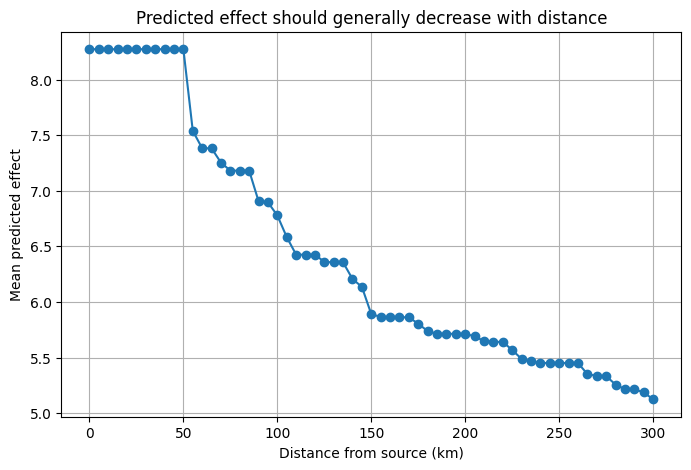

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(distance_check["distance_bin"], distance_check["predicted_effect"], marker="o")
plt.xlabel("Distance from source (km)")
plt.ylabel("Mean predicted effect")
plt.title("Predicted effect should generally decrease with distance")
plt.grid(True)
plt.show()